In [1]:
import torch
import sys
import time

sys.path.append("/home/hpc/v120bb/v120bb18/UnReflectAnything")
from utilities.visualization import rgb, panelize
from polar_highlighter import PolarHighlighter

if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    curr_device = torch.cuda.current_device()
    device_name = torch.cuda.get_device_name(curr_device)
    print(f"CUDA is available: {num_devices} device(s) detected.")
    print(f"Current device id: {curr_device} - {device_name}")
else:
    print("CUDA is not available")
%load_ext autoreload
%autoreload 2


CUDA is available: 1 device(s) detected.
Current device id: 0 - NVIDIA A100-SXM4-80GB


In [2]:
from main import load_and_process_config
from models import load_best_model_by_run
from dataset import from_config
from utilities import tensor_dict_summarize


config = load_and_process_config("config_test.yaml")
config.RUN = "fine-water-334"
highlighter = PolarHighlighter(width=448, height=448).cuda()
dataset = from_config(config)["test"]
model = load_best_model_by_run(config.RUN).eval().cuda()

DATASET  [16:06:39] Processing 1 datasets: ['SCARED']

DATASET  [16:06:39] Using all scenes except VAL_SCENES for SCARED training

DATASET  [16:06:39]   ✓ Created training dataset for SCARED: 15420 samples (excluding 13 val scenes)

DATASET  [16:06:39]   ✓ Created validation dataset for SCARED: 11323 samples from 13 scenes

DATASET  [16:06:39] === Dataset Creation Summary ===

...

DATASET  [16:06:39] Test:       11323 total samples

INFO     [16:06:40] Found valid run to resume: /anvme/workspace/v120bb18-unreflectanything/results/fine-water-334

INFO     [16:06:40] Latest checkpoint: 
/anvme/workspace/v120bb18-unreflectanything/results/fine-water-334/models/weights_best.pt

INFO     [16:06:40] Latest epoch: 14

MODEL    [16:06:40] Model with class RGBDistillDecomposer created with 98,506,147 parameters

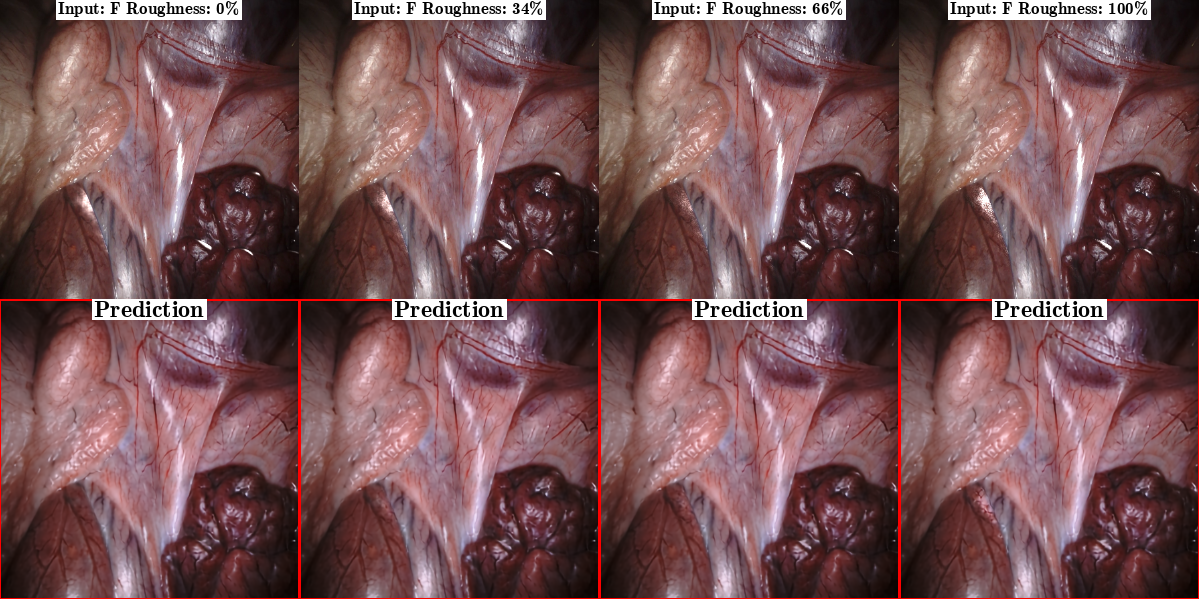

In [ ]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)

for batch in dataloader:
    batch = {
        k: v.cuda() if isinstance(v, torch.Tensor) and torch.cuda.is_available() else v
        for k, v in batch.items()
    }

    # Prepare list of noise values for progressive grid, evenly spaced from 0 to 0.2
    n_steps = 4
    noise_values = [round(x, 3) for x in torch.linspace(0, 0.05, steps=n_steps).tolist()]

    panels = []
    labels = []
    highlighted_results = []
    model_outputs = []

    # Always use the same light_pos for comparability
    base_highlight = highlighter(
        batch["diffuse"],
        surface_roughness=50,
        intensity=5,
        noise=0.0,
    )
    base_light_pos = base_highlight["light_pos"]

    # # Generate highlighted images and model outputs for each noise value
    # for nval in noise_values:
    #     highlighted = highlighter(
    #         batch["diffuse"],
    #         surface_roughness=50,
    #         intensity=5,
    #         noise=nval,
    #         noise_type="fbm",
    #         noise_octaves=1,
    #         light_pos=base_light_pos,
    #     )
    #     highlighted_rgb = highlighted["rgb_highlighted"].cuda()
    #     model_input = {"rgb": highlighted_rgb}
    #     with torch.no_grad():
    #         model_out = model(model_input)
    #     # For visualization: store the highlighted image and the reconstructed diffuse
    #     highlighted_results.append(highlighted["rgb_highlighted"])
    #     # pick only the first (since batch size=1)
    #     model_outputs.append(model_out["diffuse"][0])
    #     labels.append(f"noise={nval:.2f}")

    # # First column: input image (original diffuse)
    # panels.append(rgb(batch["diffuse"], as_tensor=True, resize=(300, 300)))
    # # Second to N columns: all highlight images (top) and their model outputs (bottom)
    # highlight_imgs = [
    #     rgb(
    #         h[0],
    #         as_tensor=True,
    #         resize=(300, 300),
    #         label={"position": "top", "height": 20, "margin": 0, "text": f"Input: W Roughness: {int(nval/max(noise_values)*100)}%"},
    #     )
    #     for h, nval in zip(highlighted_results, noise_values)
    # ]
    # modelout_imgs = [
    #     rgb(
    #         m,
    #         as_tensor=True,
    #         resize=(300, 300),
    #         border={"color": "#ff0000", "thickness": 1},
    #         label={"position": "top", "height": 20, "margin": 0, "text": f"Prediction"},

    #     )
    #     for m in model_outputs
    # ]

    # # Construct a 2-row panel: top=highlighted images, bottom=model outputs
    # grid = panelize(
    #     *highlight_imgs,
    # )
    # grid2 = panelize(
    #     *modelout_imgs,
    # )
    # full_panel = panelize(
    #     # panels[0],
    #     grid,
    #     grid2,
    #     mode="vertical",
    # )

    # rgb(full_panel)
    panels = []
    labels = []
    highlighted_results = []
    model_outputs = []
    # Generate highlighted images and model outputs for each noise value
    for nval in noise_values:
        highlighted = highlighter(
            batch["diffuse"],
            surface_roughness=50,
            intensity=2,
            noise=0.03,
            noise_type="fbm",
            noise_octaves=4,
            noise_persistence=0.75,
            light_pos=base_light_pos,
        )
        highlighted_rgb = highlighted["rgb_highlighted"].cuda()
        model_input = {"rgb": highlighted_rgb}
        with torch.no_grad():
            model_out = model(model_input)
        # For visualization: store the highlighted image and the reconstructed diffuse
        highlighted_results.append(highlighted["rgb_highlighted"])
        # pick only the first (since batch size=1)
        model_outputs.append(model_out["diffuse"][0])
        labels.append(f"noise={nval:.2f}")

    # First column: input image (original diffuse)
    panels.append(rgb(batch["diffuse"], as_tensor=True, resize=(300, 300)))
    # Second to N columns: all highlight images (top) and their model outputs (bottom)
    highlight_imgs = [
        rgb(
            h[0],
            as_tensor=True,
            resize=(300, 300),
            label={"position": "top", "height": 20, "margin": 0, "text": f"Input: F Roughness: {int(nval/max(noise_values)*100)}%"},
        )
        for h, nval in zip(highlighted_results, noise_values)
    ]
    modelout_imgs = [
        rgb(
            m,
            as_tensor=True,
            resize=(300, 300),
            border={"color": "#ff0000", "thickness": 1},
            label={"position": "top", "height": 20, "margin": 0, "text": f"Prediction"},

        )
        for m in model_outputs
    ]

    # Construct a 2-row panel: top=highlighted images, bottom=model outputs
    grid = panelize(
        *highlight_imgs,
    )
    grid2 = panelize(
        *modelout_imgs,
    )
    full_panel = panelize(
        # panels[0],
        grid,
        grid2,
        mode="vertical",
    )

    rgb(full_panel)
    break


In [ ]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=True)

for batch in dataloader:
    batch = {
        k: v.cuda() if isinstance(v, torch.Tensor) and torch.cuda.is_available() else v
        for k, v in batch.items()
    }

    # Prepare list of noise values for progressive grid, evenly spaced from 0 to 0.2
    n_steps = 4
    noise_values = [round(x, 3) for x in torch.linspace(0, 0.2, steps=n_steps).tolist()]

    panels = []
    labels = []
    highlighted_results = []
    model_outputs = []

    # Always use the same light_pos for comparability
    base_highlight = highlighter(
        batch["diffuse"],
        surface_roughness=50,
        intensity=5,
        noise=0.0,
    )
    base_light_pos = base_highlight["light_pos"]

    # Generate highlighted images and model outputs for each noise value
    for nval in noise_values:
        highlighted = highlighter(
            batch["diffuse"],
            surface_roughness=50,
            intensity=5,
            noise=nval,
            noise_type="worley",
            light_pos=base_light_pos,
        )
        highlighted_rgb = highlighted["rgb_highlighted"].cuda()
        model_input = {"rgb": highlighted_rgb}
        with torch.no_grad():
            model_out = model(model_input)
        # For visualization: store the highlighted image and the reconstructed diffuse
        highlighted_results.append(highlighted["rgb_highlighted"])
        # pick only the first (since batch size=1)
        model_outputs.append(model_out["diffuse"][0])
        labels.append(f"noise={nval:.2f}")

    # First column: input image (original diffuse)
    panels.append(rgb(batch["diffuse"], as_tensor=True, resize=(300, 300)))
    # Second to N columns: all highlight images (top) and their model outputs (bottom)
    highlight_imgs = [
        rgb(
            h,
            as_tensor=True,
            resize=(300, 300),
            label={"position": "top", "height": 20, "margin": 0, "text": f"Input: Roughness: {int(nval/max(noise_values)*100)}%"},
        )
        for h, nval in zip(highlighted_results, noise_values)
    ]
    modelout_imgs = [
        rgb(
            m,
            as_tensor=True,
            resize=(300, 300),
            border={"color": "#ff0000", "thickness": 1},
            label={"position": "top", "height": 20, "margin": 0, "text": f"Prediction"},

        )
        for m in model_outputs
    ]

    # Construct a 2-row panel: top=highlighted images, bottom=model outputs
    grid = panelize(
        *highlight_imgs,
    )
    grid2 = panelize(
        *modelout_imgs,
    )
    full_panel = panelize(
        # panels[0],
        grid,
        grid2,
        mode="vertical",
    )

    rgb(full_panel)
    break


In [22]:
with torch.no_grad():
    startt = time.time()
    modelout = model(model_input)
    fptime = time.time() - startt
    print(
        f"Forward pass on {tuple(model_input['rgb'].shape)} image: {int(fptime * 1000)}ms [{int(fptime * 1000 / model_input['rgb'].shape[0])}ms/img]"
    )


Forward pass on (32, 3, 448, 448) image: 200ms s/img]
